# LeNet-5 Evaluation and Visualization

In [2]:
import os
import sys

import pandas as pd
import tensorflow as tf

# Add the parent directory to the Python path to allow imports from sibling directories
sys.path.append(os.path.abspath(".."))

from data.dataset import prepare_mnist_dataset, prepare_cifar10_dataset
from models.lenet5 import LeNet5
from utils.trainer import LeNetTrainer
from utils.visualize import plot_training_hist_dict, plot_confusion_matrix, plot_sample_predictions

# Check TensorFlow version and available devices
print("TensorFlow Version:", tf.__version__)
print("Devices available:", tf.config.list_physical_devices())

TensorFlow Version: 2.21.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
# Configuration parameters
DATASET_NAME = "mnist"  # Options: "mnist" or "cifar10"
BATCH_SIZE = 64

# Load and preprocess dataset pipelines
if DATASET_NAME == "mnist":
    _, _, test_ds = prepare_mnist_dataset(batch_size=BATCH_SIZE)
    input_shape = (32, 32, 1)
else:
    _, _, test_ds = prepare_cifar10_dataset(batch_size=BATCH_SIZE)
    input_shape = (32, 32, 3)

print(f"\nSuccessfully loaded {DATASET_NAME.upper()} data pipelines.")

MNIST Shapes (Before Preprocessing): (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
MNIST Shapes (After Preprocessing): (54000, 32, 32, 1) (54000,) (10000, 32, 32, 1) (10000,)

Successfully loaded MNIST data pipelines.


In [4]:
# Paths for saved model and weights
MODEL_PATH = f"../saved_models/lenet5_{DATASET_NAME}.keras"
WEIGHTS_PATH = f"../saved_models/lenet5_{DATASET_NAME}.weights.h5"

# Option A: Load full saved model (.keras)
if os.path.exists(MODEL_PATH):
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Full model loaded successfully.")

# Option B: Rebuild architecture and load weights (.weights.h5)
elif os.path.exists(WEIGHTS_PATH):
    model = LeNet5(input_shape=input_shape, num_classes=10)
    model.load_weights(WEIGHTS_PATH)
    print("Model weights loaded successfully.")

else:
    raise FileNotFoundError("No saved model or weights found. Please train the model first.")

Full model loaded successfully.


In [5]:
# Display network architecture summary
model.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C1_Conv (Conv2D)                │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2_AvgPool (AveragePooling2D)   │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3_Conv (Conv2D)                │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4_AvgPool (AveragePooling2D)   │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5_Conv (Conv2D)                │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6_Dense (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,120 (723.13 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 123,414 (482.09 KB)

In [ ]:
HISTORY_PATH = f"../saved_models/lenet5_{DATASET_NAME}_history.csv"

if os.path.exists(HISTORY_PATH):
    # Load history from CSV file into a Pandas DataFrame
    history_df = pd.read_csv(HISTORY_PATH)
    print("Training history loaded successfully.")
    display(history_df.head())
else:
    raise FileNotFoundError(f"History file not found at: {HISTORY_PATH}")

# Plot training & validation loss and accuracy curves across epochs
plot_training_hist_dict(history_df, dataset_name=DATASET_NAME)

In [7]:
trainer = LeNetTrainer(model=model)

# Evaluate model performance on unseen test data
results = trainer.evaluate(test_ds, dataset_name=DATASET_NAME)

print(f"Test Accuracy ({DATASET_NAME.upper()}): {results['accuracy'] * 100:.2f}%")
print(f"Test Loss ({DATASET_NAME.upper()}): {results['loss']:.4f}")

--- Evaluating LeNet-5 on (mnist)Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9576 - loss: 0.1396 - top_5_accuracy: 0.9986
Test Accuracy (MNIST): 95.76%
Test Loss (MNIST): 0.1396


157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step


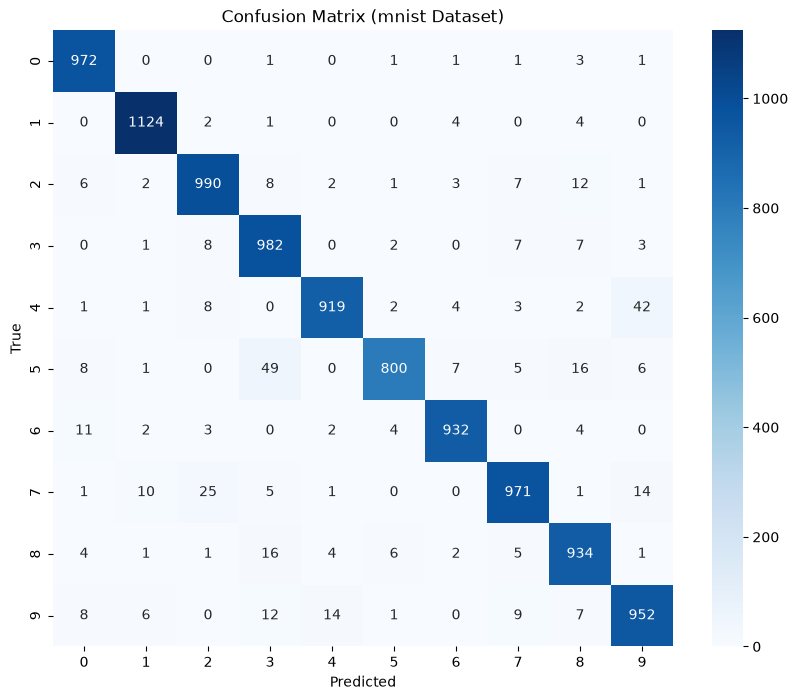

In [8]:
# Generate and display normalized confusion matrix heatmap
plot_confusion_matrix(model=model, dataset=test_ds, dataset_name=DATASET_NAME)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


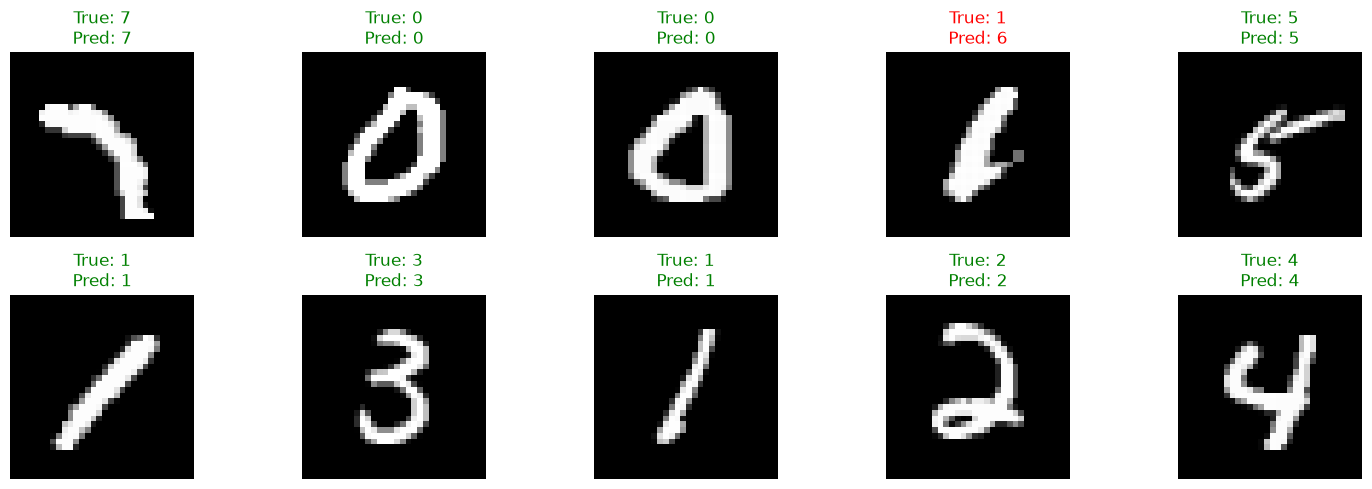

In [ ]:
# Visualize random test set samples with green/red prediction status labels
plot_sample_predictions(
    model=model,
    dataset=test_ds,
    dataset_name=DATASET_NAME,
    num_samples=10
)